# Notebook 2 — Evaluation of VLMs: established benchmarks + reinforcement-learning-based metrics

**CV claim this notebook backs up**
> *Systematic evaluation of vision-language models using established benchmarks and reinforcement-learning-based metrics.*

**What it does (everything is computed from real model runs)**

| Layer | What is measured | Benchmark / tool |
|---|---|---|
| Established benchmarks | Image captioning vs 5 human captions | **Flickr30k** |
| | Visual question answering (soft accuracy, per answer type) | **VQAv2** (validation) |
| | Cross-modal retrieval R@1/5/10, median rank (image→text, text→image) | **Flickr30k**, 1000-image pool, CLIP ViT-B/32 and ViT-L/14 |
| Classical metrics (report ch. 4) | BLEU-4, ROUGE-1/L, METEOR, CIDEr, CLIPScore, VQA accuracy, Recall@K | sacrebleu, rouge-score, nltk, pycocoevalcap, CLIP |
| RL-based metrics (report ch. 5) | (a) **CLIP reward** (ViT-B/32), (b) **Monte-Carlo expected return** J(π) over k sampled rollouts + bootstrap CI, (c) **SCST advantage** r(sample) − r(greedy), (d) **VQA rule-based reward** (soft accuracy) with sampled rollouts, (e) **best-of-k reward headroom + reward-hacking test**: captions are re-selected by the CLIP-B/32 reward and then judged by an *independent* CLIP-L/14 and by the human-reference metrics | own code |
| Hybrid (report ch. 6) | α·classical + β·reward, pooled normalisation, α-sensitivity | own code |
| Reproducibility | seeds, config, library versions, model commit hashes → `run_manifest.json` | — |

Models: **BLIP-base** (captioning), **BLIP-VQA-base** (VQA), **CLIP ViT-B/32 & ViT-L/14** (retrieval + reward/judge). The multi-architecture comparison is in notebook 3.

**Honesty notes**
* "RL-based" = rewards / returns / advantages estimated at *evaluation time* with frozen weights (no policy training).
* Subsets are small by default (captioning 200 images, retrieval pool 1000 images, VQA 300 questions). The 1000-image retrieval pool is the **first 1000 images of the dataset, not the Karpathy 1K test split**, and CIDEr's IDF is computed on the evaluated subset — so numbers are **not** comparable to published tables. CIs are reported instead.
* SPICE is not computed (it needs Java + Stanford CoreNLP); CLIPScore covers the reference-free side.


In [1]:
# ============================================================================
# 0. ENVIRONMENT  (run the installs once, in a terminal, BEFORE opening the notebook)
# ----------------------------------------------------------------------------
# RTX 50-series laptops (Blackwell, compute capability sm_120) need a PyTorch
# build compiled against CUDA 12.8 or newer:
#     pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
#     pip install -r requirements.txt
# ============================================================================
import os, sys, json, time, random, platform, re, math, itertools, warnings, gc
from importlib import metadata
warnings.filterwarnings("ignore")

os.environ["HF_HUB_DISABLE_XET"] = "1"        # avoids the stalling "reconstructing file" path
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120" # more patience on slow connections

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

# ---- GPU sanity check (fails loudly instead of silently running on CPU) ----
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Install the cu128 PyTorch build (see the top of this cell) "
                       "and make sure the NVIDIA driver is up to date.")
DEVICE = "cuda"
_cap = torch.cuda.get_device_capability(0)
_arch = f"sm_{_cap[0]}{_cap[1]}"
if _arch not in torch.cuda.get_arch_list():
    raise RuntimeError(f"This PyTorch build ({torch.__version__}) has no kernels for {_arch} "
                       f"(GPU: {torch.cuda.get_device_name(0)}). Install the cu128 build: "
                       "pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128")
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f"GPU     : {torch.cuda.get_device_name(0)}  ({_arch}, "
      f"{torch.cuda.get_device_properties(0).total_memory/2**30:.1f} GiB)")
print(f"PyTorch : {torch.__version__} | CUDA {torch.version.cuda} | dtype for generation: {DTYPE}")


GPU     : NVIDIA GeForce RTX 5070 Laptop GPU  (sm_120, 8.0 GiB)
PyTorch : 2.11.0+cu128 | CUDA 12.8 | dtype for generation: torch.bfloat16


In [2]:
# ============================================================================
# Shared utilities: statistics, reproducibility manifest, tables
# ============================================================================
def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def bootstrap_ci(x, n_boot=2000, alpha=0.05, seed=SEED):
    """Percentile bootstrap CI of the mean. Returns (mean, lo, hi)."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    means = x[idx].mean(axis=1)
    return float(x.mean()), float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2))

def paired_bootstrap(a, b, n_boot=2000, seed=SEED):
    """Paired bootstrap of mean(a-b) over items. Returns (mean_diff, lo, hi, P(diff<=0))."""
    d = np.asarray(a, float) - np.asarray(b, float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(n_boot, len(d)))
    m = d[idx].mean(axis=1)
    return float(d.mean()), float(np.quantile(m, 0.025)), float(np.quantile(m, 0.975)), float((m <= 0).mean())

def ci_str(t, nd=3):
    m, lo, hi = t
    return f"{m:.{nd}f} [{lo:.{nd}f}, {hi:.{nd}f}]"

def minmax(x, lo=None, hi=None):
    x = np.asarray(x, dtype=float)
    lo = x.min() if lo is None else lo
    hi = x.max() if hi is None else hi
    return (x - lo) / (hi - lo + 1e-12)

def df_to_md(df, nd=3):
    cols = list(df.columns)
    def f(v):
        return f"{v:.{nd}f}" if isinstance(v, (float, np.floating)) else str(v)
    lines = ["| " + " | ".join(map(str, cols)) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, r in df.iterrows():
        lines.append("| " + " | ".join(f(r[c]) for c in cols) + " |")
    return "\n".join(lines)

def write_manifest(path, config, extra=None):
    """Everything needed to reproduce / audit a run."""
    pk = ["torch", "transformers", "datasets", "accelerate", "sacrebleu", "rouge-score", "nltk",
          "bert-score", "pycocoevalcap", "scipy", "numpy", "pandas", "pillow"]
    ver = {}
    for p in pk:
        try: ver[p] = metadata.version(p)
        except Exception: ver[p] = None
    man = dict(
        timestamp=time.strftime("%Y-%m-%d %H:%M:%S"),
        python=sys.version.split()[0], platform=platform.platform(),
        gpu=torch.cuda.get_device_name(0), cuda=torch.version.cuda, torch=torch.__version__,
        versions=ver, seed=SEED, config=config, **(extra or {}),
    )
    with open(path, "w") as fh:
        json.dump(man, fh, indent=2, default=str)
    return man


In [3]:
OUT_DIR = "outputs_vlm"; os.makedirs(OUT_DIR, exist_ok=True)
CFG = dict(
    caption_model="Salesforce/blip-image-captioning-base",
    vqa_model="Salesforce/blip-vqa-base",
    clip_reward="openai/clip-vit-base-patch32",       # RL reward model (the policy is optimised/selected against this)
    clip_judge="openai/clip-vit-large-patch14",       # independent judge, never used as reward
    n_retrieval=1000, n_caption=200, n_vqa=300,
    k_samples=4, temperature=1.0, top_p=0.9, max_new_tokens=30, gen_batch=16,
    alpha=0.4, beta=0.6,
)
print(json.dumps(CFG, indent=2))

{
  "caption_model": "Salesforce/blip-image-captioning-base",
  "vqa_model": "Salesforce/blip-vqa-base",
  "clip_reward": "openai/clip-vit-base-patch32",
  "clip_judge": "openai/clip-vit-large-patch14",
  "n_retrieval": 1000,
  "n_caption": 200,
  "n_vqa": 300,
  "k_samples": 4,
  "temperature": 1.0,
  "top_p": 0.9,
  "max_new_tokens": 30,
  "gen_batch": 16,
  "alpha": 0.4,
  "beta": 0.6
}


In [4]:
# ============================================================================
# Classical captioning metrics (identical code for every model that is scored)
# ============================================================================
import nltk
for _pkg in ["wordnet", "omw-1.4"]:
    nltk.download(_pkg, quiet=True)
import sacrebleu
from rouge_score import rouge_scorer
from nltk.translate.meteor_score import meteor_score
from pycocoevalcap.cider.cider import Cider

_rouge = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

def norm_cap(s):
    return " ".join(re.findall(r"[a-z0-9']+", s.lower()))

def caption_metrics(preds, refs):
    """preds: list[str]; refs: list[list[str]] (multi-reference).
    Returns (summary dict, per-sample DataFrame). Text is lower-cased / punctuation-stripped
    identically for candidates and references."""
    P = [norm_cap(p) for p in preds]
    R = [[norm_cap(r) for r in rs] for rs in refs]
    m = min(len(r) for r in R)
    bleu = sacrebleu.corpus_bleu(P, [[r[i] for r in R] for i in range(m)]).score / 100.0
    r1, rL, met = [], [], []
    for p, rs in zip(P, R):
        r1.append(max(_rouge.score(r, p)["rouge1"].fmeasure for r in rs))
        rL.append(max(_rouge.score(r, p)["rougeL"].fmeasure for r in rs))
        met.append(meteor_score([r.split() for r in rs], p.split()))
    cider, cider_i = Cider().compute_score({i: R[i] for i in range(len(P))}, {i: [P[i]] for i in range(len(P))})
    per = pd.DataFrame({"rouge1": r1, "rougeL": rL, "meteor": met, "cider": np.asarray(cider_i)})
    summ = dict(bleu4=bleu, rouge1=float(np.mean(r1)), rougeL=float(np.mean(rL)),
                meteor=float(np.mean(met)), cider=float(cider))
    return summ, per


In [5]:
# ============================================================================
# CLIP tooling: reward model (image<->text alignment) + cross-modal retrieval
# ============================================================================
from transformers import CLIPModel, CLIPProcessor

def _feat(o):
    return o.pooler_output if hasattr(o, "pooler_output") else o

class ClipScorer:
    def __init__(self, model_id):
        self.model_id = model_id
        self.proc = CLIPProcessor.from_pretrained(model_id)
        self.model = CLIPModel.from_pretrained(model_id).to(DEVICE, torch.float16).eval()

    @torch.no_grad()
    def embed_images(self, images, bs=64):
        out = []
        for i in range(0, len(images), bs):
            pv = self.proc(images=images[i:i + bs], return_tensors="pt")["pixel_values"].to(DEVICE, torch.float16)
            e = _feat(self.model.get_image_features(pixel_values=pv)).float()
            out.append(torch.nn.functional.normalize(e, dim=-1).cpu())
        return torch.cat(out)

    @torch.no_grad()
    def embed_texts(self, texts, bs=256):
        out = []
        for i in range(0, len(texts), bs):
            t = self.proc(text=texts[i:i + bs], return_tensors="pt", padding=True, truncation=True, max_length=77).to(DEVICE)
            e = _feat(self.model.get_text_features(input_ids=t["input_ids"], attention_mask=t["attention_mask"])).float()
            out.append(torch.nn.functional.normalize(e, dim=-1).cpu())
        return torch.cat(out)

    def reward(self, img_emb, texts):
        """Per-item cosine(image, text) - the RL reward. CLIPScore (Hessel et al.) = 2.5 * max(cos, 0)."""
        return (img_emb * self.embed_texts(texts)).sum(-1).numpy()

    def close(self):
        del self.model; free_gpu()

def retrieval_metrics(img_emb, txt_emb, txt2img):
    """Flickr-style protocol: N images, several captions each.
    i2t: an image counts as retrieved if ANY of its GT captions is within top-K. t2i: each caption -> its image."""
    sim = (img_emb @ txt_emb.T).numpy()                    # [N, T]
    txt2img = np.asarray(txt2img)
    N = sim.shape[0]
    order = np.argsort(-sim, axis=1)
    i2t = np.array([np.where(txt2img[order[i]] == i)[0].min() for i in range(N)])
    order_t = np.argsort(-sim.T, axis=1)
    t2i = np.array([np.where(order_t[j] == txt2img[j])[0][0] for j in range(sim.shape[1])])
    out = {}
    for name, ranks in (("i2t", i2t), ("t2i", t2i)):
        for k in (1, 5, 10):
            out[f"{name}_R@{k}"] = 100.0 * float((ranks < k).mean())
        out[f"{name}_medR"] = float(np.median(ranks) + 1)
    out["rsum"] = sum(out[f"{n}_R@{k}"] for n in ("i2t", "t2i") for k in (1, 5, 10))
    return out


In [6]:
# ============================================================================
# Data: Flickr30k (real images + 5 human captions each), streamed from the HF Hub
# ============================================================================
from datasets import load_dataset

FLICKR_CANDIDATES = [("lmms-lab/flickr30k", "test"), ("nlphuji/flickr30k", "test")]

def load_flickr(n):
    last = None
    for ds_id, split in FLICKR_CANDIDATES:
        try:
            print(f"Streaming {ds_id}[{split}] ({n} images)...")
            try:
                ds = load_dataset(ds_id, split=split, streaming=True)
            except Exception:
                ds = load_dataset(ds_id, split=split, streaming=True, trust_remote_code=True)
            items = list(itertools.islice(ds, n))
            images, refs = [], []
            for it in items:
                images.append(it["image"].convert("RGB"))
                c = it["caption"]
                refs.append([c] if isinstance(c, str) else list(c))
            m = min(len(r) for r in refs)
            assert m >= 1
            print(f"OK  {len(images)} images, >= {m} human captions each  (source: {ds_id})")
            return images, refs, ds_id
        except Exception as e:
            last = e
            print(f"  could not use {ds_id}: {type(e).__name__}: {str(e)[:150]}")
    raise RuntimeError(f"No Flickr30k source worked. Last error: {last}")


In [7]:
# ============================================================================
# 1. Load real data ONCE: Flickr30k images + human captions (pool for retrieval; first n_caption used for captioning)
# ============================================================================
images_all, refs_all, FLICKR_SRC = load_flickr(CFG["n_retrieval"])

Streaming lmms-lab/flickr30k[test] (1000 images)...


OK  1000 images, >= 5 human captions each  (source: lmms-lab/flickr30k)


In [8]:
# ============================================================================
# VQAv2 (real questions, 10 human answers each). Loading is best-effort: if the Hub source
# is unavailable the VQA part is skipped (and the summary says so) - it never fakes data.
# ============================================================================
VQA_CANDIDATES = [("lmms-lab/VQAv2", "validation"), ("HuggingFaceM4/VQAv2", "validation")]

def load_vqa(n):
    for ds_id, split in VQA_CANDIDATES:
        try:
            print(f"Streaming {ds_id}[{split}] ({n} questions)...")
            ds = load_dataset(ds_id, split=split, streaming=True)
            items = list(itertools.islice(ds, n))
            out = []
            for it in items:
                ans = it["answers"]
                ans = [a["answer"] if isinstance(a, dict) else a for a in ans]
                out.append(dict(image=it["image"].convert("RGB"), question=it["question"], answers=ans,
                                atype=it.get("answer_type", "unknown")))
            print(f"OK  {len(out)} VQA items (source: {ds_id})")
            return out, ds_id
        except Exception as e:
            print(f"  could not use {ds_id}: {type(e).__name__}: {str(e)[:150]}")
    return None, None

VQA_ITEMS, VQA_SRC = load_vqa(CFG["n_vqa"])
_ART = re.compile(r"\b(a|an|the)\b")
def norm_ans(s): return " ".join(_ART.sub(" ", re.sub(r"[^a-z0-9 ]", " ", s.lower())).split())
def vqa_acc(pred, answers):
    """Report ch. 4, eq. 1.4:  Acc = min(#humans who gave that answer / 3, 1)  (simplified, not the official 10-choose-9 average)."""
    p = norm_ans(pred); return min(sum(norm_ans(a) == p for a in answers) / 3.0, 1.0)

Streaming lmms-lab/VQAv2[validation] (300 questions)...


Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

OK  300 VQA items (source: lmms-lab/VQAv2)


In [9]:
# ============================================================================
# 2. Captioning rollouts with BLIP: greedy baseline + k stochastic samples (policy rollouts)
# ============================================================================
from transformers import BlipProcessor, BlipForConditionalGeneration, BlipForQuestionAnswering

def _load(cls, mid):
    try: m = cls.from_pretrained(mid, dtype=DTYPE)
    except TypeError: m = cls.from_pretrained(mid, torch_dtype=DTYPE)
    return m.to(DEVICE).eval()

def blip_caption(images, sample=False):
    out = []
    for i in tqdm(range(0, len(images), CFG["gen_batch"]), desc="BLIP sample" if sample else "BLIP greedy", leave=False):
        pv = proc_c(images=images[i:i + CFG["gen_batch"]], return_tensors="pt")["pixel_values"].to(DEVICE, DTYPE)
        kw = dict(max_new_tokens=CFG["max_new_tokens"])
        kw.update(dict(do_sample=True, temperature=CFG["temperature"], top_p=CFG["top_p"], top_k=0) if sample
                  else dict(do_sample=False))
        with torch.no_grad(): ids = model_c.generate(pixel_values=pv, **kw)
        out += [c.strip() for c in proc_c.batch_decode(ids, skip_special_tokens=True)]
    return out

set_seed(); torch.cuda.reset_peak_memory_stats()
cap_images, cap_refs = images_all[:CFG["n_caption"]], refs_all[:CFG["n_caption"]]
proc_c = BlipProcessor.from_pretrained(CFG["caption_model"]); model_c = _load(BlipForConditionalGeneration, CFG["caption_model"])
cap_commit = getattr(model_c.config, "_commit_hash", None)
t0 = time.time(); greedy_caps = blip_caption(cap_images); t_greedy = time.time() - t0
sampled_caps = [blip_caption(cap_images, sample=True) for _ in range(CFG["k_samples"])]     # [K][N]
sampled_caps = [list(x) for x in zip(*sampled_caps)]                                        # [N][K]
del model_c; free_gpu()
print(f"greedy: {t_greedy:.1f}s for {len(cap_images)} images | example: {greedy_caps[0]!r}")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP greedy:   0%|          | 0/13 [00:00<?, ?it/s]

BLIP sample:   0%|          | 0/13 [00:00<?, ?it/s]

BLIP sample:   0%|          | 0/13 [00:00<?, ?it/s]

BLIP sample:   0%|          | 0/13 [00:00<?, ?it/s]

BLIP sample:   0%|          | 0/13 [00:00<?, ?it/s]

greedy: 3.6s for 200 images | example: 'a man standing in the grass'


In [11]:
# ============================================================================
# 3. CLASSICAL metrics (report ch. 4)  +  4. CLIP rewards & retrieval
# ============================================================================
cap_summ, cap_per = caption_metrics(greedy_caps, cap_refs)

clip_r = ClipScorer(CFG["clip_reward"]); clip_j = ClipScorer(CFG["clip_judge"])
E_r = clip_r.embed_images(images_all);  E_j = clip_j.embed_images(images_all)       # all retrieval images, once
n_c = len(cap_images); K = CFG["k_samples"]

def rewards(scorer, E, caps_greedy, caps_samples):
    g = scorer.reward(E[:n_c], caps_greedy)
    flat = [s for ss in caps_samples for s in ss]
    s = scorer.reward(E[:n_c].repeat_interleave(K, dim=0), flat).reshape(n_c, K)
    return g, s

rg_r, rs_r = rewards(clip_r, E_r, greedy_caps, sampled_caps)      # RL reward (B/32)
rg_j, rs_j = rewards(clip_j, E_j, greedy_caps, sampled_caps)      # independent judge (L/14)
cap_summ["clip_cos_B32"] = float(rg_r.mean()); cap_summ["clipscore_B32"] = float((2.5 * np.maximum(rg_r, 0)).mean())
cap_summ["clip_cos_L14"] = float(rg_j.mean()); cap_summ["clipscore_L14"] = float((2.5 * np.maximum(rg_j, 0)).mean())

# ---- cross-modal retrieval on the 1000-image pool (5 captions per image) ----
flat_refs = [norm_cap(c) for rs in refs_all for c in rs[:5]]
txt2img = [i for i, rs in enumerate(refs_all) for _ in rs[:5]]
RET = {}
for tag, sc, E in (("CLIP ViT-B/32", clip_r, E_r), ("CLIP ViT-L/14", clip_j, E_j)):
    RET[tag] = retrieval_metrics(E, sc.embed_texts(flat_refs), txt2img)
ret_df = pd.DataFrame(RET).T.round(2)
print(f"Captioning ({n_c} imgs):", {k: round(v, 4) for k, v in cap_summ.items()})
print("\nRetrieval (pool of", len(images_all), "images):"); print(ret_df.to_string())

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/openai/clip-vit-large-patch14/resolve/main/model.safetensors: The read operation timed out
Trying to resume download...
Trying to resume download...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Captioning (200 imgs): {'bleu4': 0.2467, 'rouge1': 0.5045, 'rougeL': 0.4765, 'meteor': 0.3686, 'cider': 0.5128, 'clip_cos_B32': 0.286, 'clipscore_B32': 0.7151, 'clip_cos_L14': 0.2333, 'clipscore_L14': 0.5832}

Retrieval (pool of 1000 images):
               i2t_R@1  i2t_R@5  i2t_R@10  i2t_medR  t2i_R@1  t2i_R@5  t2i_R@10  t2i_medR    rsum
CLIP ViT-B/32     76.9     95.9      98.3       1.0    59.76    84.42     90.78       1.0  506.06
CLIP ViT-L/14     84.5     97.5      99.2       1.0    66.22    88.56     92.90       1.0  528.88


In [12]:
# ============================================================================
# 5. RL-BASED metrics for captioning (report ch. 5)
# ============================================================================
# (b) Monte-Carlo expected return  J(pi) = E_{y~pi}[ r_CLIP(x,y) ]   (k rollouts per image)
J_img = rs_r.mean(1)
# (c) SCST advantage  A = r(sample) - r(greedy baseline)      (Rennie et al., 2017)
A_img = J_img - rg_r
A_traj = rs_r - rg_r[:, None]
# reward variance across rollouts = how much exploitable signal the policy exposes
R_std = rs_r.std(1)

# (e) best-of-k with the RL reward, then check for REWARD HACKING with independent metrics
cand = [[g] + list(ss) for g, ss in zip(greedy_caps, sampled_caps)]                   # k+1 candidates per image
cand_r = np.concatenate([rg_r[:, None], rs_r], 1)
pick = cand_r.argmax(1)
bok_caps = [c[p] for c, p in zip(cand, pick)]
bok_summ, bok_per = caption_metrics(bok_caps, cap_refs)
bok_rj = clip_j.reward(E_j[:n_c], bok_caps)
hack = pd.DataFrame({
    "metric": ["CLIP-B/32 cos (optimised reward)", "CLIP-L/14 cos (independent judge)", "METEOR (human refs)",
               "ROUGE-L (human refs)", "CIDEr (human refs)", "avg caption length (words)"],
    "greedy": [rg_r.mean(), rg_j.mean(), cap_summ["meteor"], cap_summ["rougeL"], cap_summ["cider"],
               np.mean([len(c.split()) for c in greedy_caps])],
    "best-of-k by reward": [cand_r.max(1).mean(), bok_rj.mean(), bok_summ["meteor"], bok_summ["rougeL"], bok_summ["cider"],
                            np.mean([len(c.split()) for c in bok_caps])],
})
hack["delta"] = hack["best-of-k by reward"] - hack["greedy"]

# does the RL reward agree with human-reference metrics, per image?
from scipy.stats import spearmanr
corr = {m: float(spearmanr(rg_r, cap_per[m])[0]) for m in ("meteor", "rougeL", "cider")}

print(f"J(pi) MC return      : {ci_str(bootstrap_ci(J_img))}   | greedy reward: {ci_str(bootstrap_ci(rg_r))}")
print(f"SCST advantage       : {ci_str(bootstrap_ci(A_img), 4)}   | % rollouts beating greedy: {100*(A_traj>0).mean():.1f}%")
print(f"Reward std over rollouts (mean): {R_std.mean():.4f}")
print("\nBest-of-k reward headroom & reward-hacking check (positive delta on the optimised reward, "
      "but flat/negative delta on the independent metrics = the reward is being exploited):")
print(hack.round(4).to_string(index=False))
print("\nSpearman(CLIP-B/32 reward, human-reference metric) per image:", {k: round(v, 3) for k, v in corr.items()})

J(pi) MC return      : 0.254 [0.250, 0.258]   | greedy reward: 0.286 [0.281, 0.291]
SCST advantage       : -0.0316 [-0.0367, -0.0266]   | % rollouts beating greedy: 27.8%
Reward std over rollouts (mean): 0.0328

Best-of-k reward headroom & reward-hacking check (positive delta on the optimised reward, but flat/negative delta on the independent metrics = the reward is being exploited):
                           metric  greedy  best-of-k by reward   delta
 CLIP-B/32 cos (optimised reward)  0.2860               0.3054  0.0193
CLIP-L/14 cos (independent judge)  0.2333               0.2467  0.0134
              METEOR (human refs)  0.3686               0.3282 -0.0405
             ROUGE-L (human refs)  0.4765               0.4100 -0.0665
               CIDEr (human refs)  0.5128               0.4423 -0.0705
       avg caption length (words)  6.7000               7.8150  1.1150

Spearman(CLIP-B/32 reward, human-reference metric) per image: {'meteor': 0.406, 'rougeL': 0.35, 'cider': 0.471}


In [13]:
# ============================================================================
# 6. VQAv2: classical soft accuracy + RL reward (rule-based) with sampled rollouts
# ============================================================================
vqa_out = None
if VQA_ITEMS:
    set_seed()
    proc_q = BlipProcessor.from_pretrained(CFG["vqa_model"]); model_q = _load(BlipForQuestionAnswering, CFG["vqa_model"])
    def vqa_answer(items, sample=False):
        out = []
        for i in tqdm(range(0, len(items), CFG["gen_batch"]), desc="VQA", leave=False):
            b = items[i:i + CFG["gen_batch"]]
            enc = proc_q(images=[x["image"] for x in b], text=[x["question"] for x in b], return_tensors="pt", padding=True)
            kw = dict(max_new_tokens=10)
            kw.update(dict(do_sample=True, temperature=CFG["temperature"], top_p=CFG["top_p"], top_k=0) if sample else dict(do_sample=False))
            with torch.no_grad():
                ids = model_q.generate(input_ids=enc["input_ids"].to(DEVICE), attention_mask=enc["attention_mask"].to(DEVICE),
                                       pixel_values=enc["pixel_values"].to(DEVICE, DTYPE), **kw)
            out += [a.strip() for a in proc_q.batch_decode(ids, skip_special_tokens=True)]
        return out
    vqa_greedy = vqa_answer(VQA_ITEMS)
    vqa_samples = [list(x) for x in zip(*[vqa_answer(VQA_ITEMS, True) for _ in range(K)])]
    del model_q; free_gpu()
    g_acc = np.array([vqa_acc(p, it["answers"]) for p, it in zip(vqa_greedy, VQA_ITEMS)])
    s_acc = np.array([[vqa_acc(p, it["answers"]) for p in ss] for ss, it in zip(vqa_samples, VQA_ITEMS)])
    vqa_df = pd.DataFrame({"atype": [it["atype"] for it in VQA_ITEMS], "greedy_acc": g_acc,
                           "J_mc": s_acc.mean(1), "advantage": s_acc.mean(1) - g_acc, "any_of_k": s_acc.max(1)})
    vqa_out = dict(acc=bootstrap_ci(g_acc), J=bootstrap_ci(vqa_df.J_mc), adv=bootstrap_ci(vqa_df.advantage), any_k=bootstrap_ci(vqa_df.any_of_k))
    print(f"VQA accuracy (greedy)   : {ci_str(vqa_out['acc'])}")
    print(f"VQA J(pi) MC return     : {ci_str(vqa_out['J'])}   (k={K} sampled answers per question)")
    print(f"VQA SCST advantage      : {ci_str(vqa_out['adv'])}")
    print(f"VQA any-of-{K} (oracle)   : {ci_str(vqa_out['any_k'])}")
    print("\nPer answer type (greedy accuracy):"); print(vqa_df.groupby("atype")["greedy_acc"].agg(["mean", "count"]).round(3))
else:
    print("VQA skipped: no VQAv2 source could be loaded (see messages above). Nothing was fabricated.")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

VQA:   0%|          | 0/19 [00:00<?, ?it/s]

VQA:   0%|          | 0/19 [00:00<?, ?it/s]

VQA:   0%|          | 0/19 [00:00<?, ?it/s]

VQA:   0%|          | 0/19 [00:00<?, ?it/s]

VQA accuracy (greedy)   : 0.847 [0.808, 0.883]
VQA J(pi) MC return     : 0.711 [0.675, 0.750]   (k=4 sampled answers per question)
VQA SCST advantage      : -0.136 [-0.168, -0.103]
VQA any-of-4 (oracle)   : 0.882 [0.848, 0.916]

Per answer type (greedy accuracy):
         mean  count
atype               
number  0.592     40
other   0.828    149
yes/no  0.964    111


In [14]:
# ============================================================================
# 7. HYBRID score (report ch. 6)  +  alpha sensitivity  (per-image, greedy captions)
# ============================================================================
classical = ((cap_per["rougeL"] + cap_per["meteor"]) / 2).values
r_norm = minmax(rg_r)
def hyb(a): return a * classical + (1 - a) * r_norm
hybrid_default = CFG["alpha"] * classical + CFG["beta"] * r_norm
sens = pd.Series({a: float(hyb(a).mean()) for a in np.round(np.linspace(0, 1, 11), 2)})
print(f"Hybrid score (alpha={CFG['alpha']}, beta={CFG['beta']}): {ci_str(bootstrap_ci(hybrid_default), 4)}")
print("Sensitivity to alpha:"); print(sens.round(4).to_string())

Hybrid score (alpha=0.4, beta=0.6): 0.4263 [0.4068, 0.4457]
Sensitivity to alpha:
0.0    0.4288
0.1    0.4281
0.2    0.4275
0.3    0.4269
0.4    0.4263
0.5    0.4257
0.6    0.4250
0.7    0.4244
0.8    0.4238
0.9    0.4232
1.0    0.4226


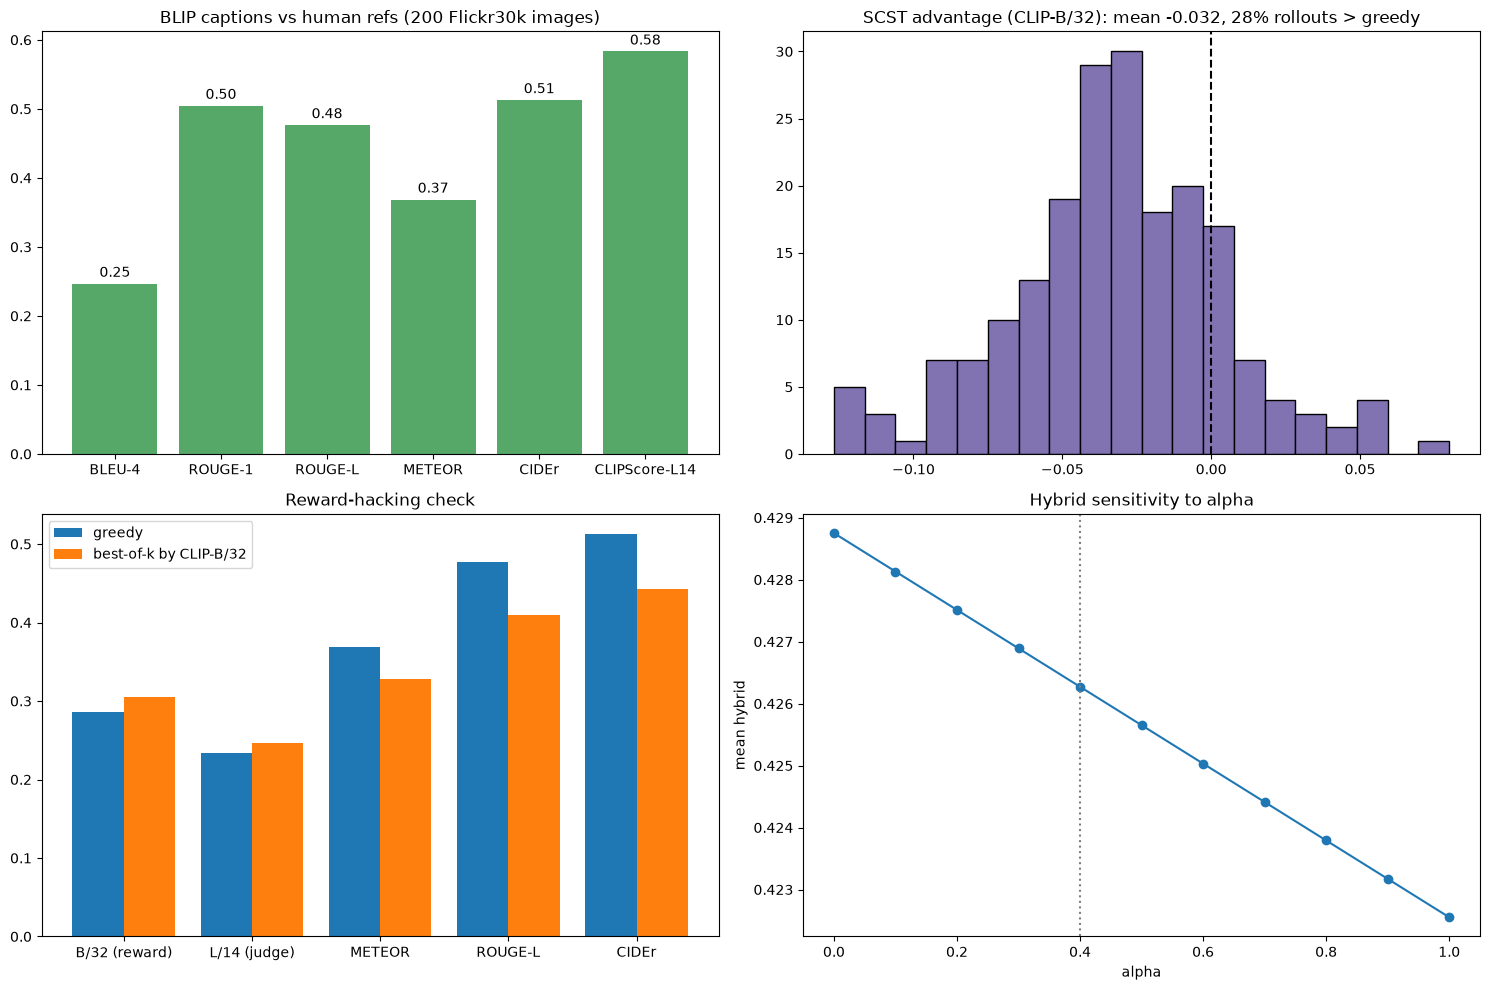

[0] greedy: 'a man standing in the grass' | best-of-k: 'green bush behind a boy' | ref: 'Two young guys with shaggy hair look at their hands while hanging out in the yard .'
[1] greedy: 'a metal tower' | best-of-k: 'there is a man on a telephone high up in the sky' | ref: 'Several men in hard hats are operating a giant pulley system .'
[2] greedy: 'a little girl in a pink dress' | best-of-k: 'plants to grow inside an open chicken coop' | ref: 'A child in a pink dress is climbing up a set of stairs in an entry way .'
[3] greedy: 'a man on a ladder' | best-of-k: 'a man on a building holding a saw' | ref: 'Someone in a blue shirt and hat is standing on stair and leaning against a window .'

## VLM results (BLIP-base captioning, BLIP-VQA, CLIP retrieval)

Captioning, 200 Flickr30k images: BLEU-4 0.247, ROUGE-L 0.476, METEOR 0.369, CIDEr 0.513, CLIPScore(L/14) 0.583

RL metrics: J(pi)=0.2544 [0.2502, 0.2585], SCST advantage=-0.0316 [-0.0367, -0.0266], hybrid=0.4263 [0.4068, 0.4457]

### Ret

In [15]:
# ============================================================================
# 8. Save + plots + paste-ready markdown
# ============================================================================
summary = dict(
    captioning={k: round(float(v), 4) for k, v in cap_summ.items()},
    rl_captioning=dict(J_mc=ci_str(bootstrap_ci(J_img), 4), greedy_reward=ci_str(bootstrap_ci(rg_r), 4),
                       scst_advantage=ci_str(bootstrap_ci(A_img), 4), pct_rollouts_beating_greedy=round(100 * float((A_traj > 0).mean()), 1),
                       reward_std_over_rollouts=round(float(R_std.mean()), 4), spearman_reward_vs_refs=corr),
    hybrid=ci_str(bootstrap_ci(hybrid_default), 4),
    retrieval=RET, vqa=({k: ci_str(v) for k, v in vqa_out.items()} if vqa_out else "skipped"),
)
json.dump(summary, open(f"{OUT_DIR}/vlm_results.json", "w"), indent=2, default=str)
hack.to_csv(f"{OUT_DIR}/vlm_best_of_k_reward_hacking.csv", index=False); ret_df.to_csv(f"{OUT_DIR}/vlm_retrieval.csv")
pd.DataFrame({"greedy_caption": greedy_caps, "best_of_k_caption": bok_caps, "reference_0": [r[0] for r in cap_refs],
              "clip_reward": rg_r, "clip_reward_mean_samples": J_img, "scst_advantage": A_img,
              "hybrid": hybrid_default, **{k: cap_per[k] for k in cap_per.columns}}).to_csv(f"{OUT_DIR}/vlm_caption_per_sample.csv", index=False)
if vqa_out is not None: vqa_df.to_csv(f"{OUT_DIR}/vlm_vqa_per_sample.csv", index=False)
write_manifest(f"{OUT_DIR}/run_manifest.json", CFG, extra=dict(caption_model_commit=cap_commit, flickr_source=FLICKR_SRC, vqa_source=VQA_SRC))

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
names = ["BLEU-4", "ROUGE-1", "ROUGE-L", "METEOR", "CIDEr", "CLIPScore-L14"]
vals = [cap_summ["bleu4"], cap_summ["rouge1"], cap_summ["rougeL"], cap_summ["meteor"], cap_summ["cider"], cap_summ["clipscore_L14"]]
ax[0, 0].bar(names, vals, color="#55A868"); ax[0, 0].set_title(f"BLIP captions vs human refs ({n_c} Flickr30k images)")
for i, v in enumerate(vals): ax[0, 0].text(i, v + 0.01, f"{v:.2f}", ha="center")
ax[0, 1].hist(A_img, bins=20, color="#8172B2", edgecolor="k"); ax[0, 1].axvline(0, color="k", ls="--")
ax[0, 1].set_title(f"SCST advantage (CLIP-B/32): mean {A_img.mean():.3f}, {100*(A_traj>0).mean():.0f}% rollouts > greedy")
h = hack.iloc[:5].copy(); x = np.arange(len(h)); ax[1, 0].bar(x - 0.2, h["greedy"], 0.4, label="greedy"); ax[1, 0].bar(x + 0.2, h["best-of-k by reward"], 0.4, label="best-of-k by CLIP-B/32")
ax[1, 0].set_xticks(x); ax[1, 0].set_xticklabels(["B/32 (reward)", "L/14 (judge)", "METEOR", "ROUGE-L", "CIDEr"]); ax[1, 0].legend(); ax[1, 0].set_title("Reward-hacking check")
ax[1, 1].plot(sens.index, sens.values, marker="o"); ax[1, 1].axvline(CFG["alpha"], color="gray", ls=":")
ax[1, 1].set_xlabel("alpha"); ax[1, 1].set_ylabel("mean hybrid"); ax[1, 1].set_title("Hybrid sensitivity to alpha")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/vlm_evaluation_plots.png", dpi=150); plt.show()

# example qualitative rows
for i in range(4):
    print(f"[{i}] greedy: {greedy_caps[i]!r} | best-of-k: {bok_caps[i]!r} | ref: {cap_refs[i][0]!r}")

md = ("## VLM results (BLIP-base captioning, BLIP-VQA, CLIP retrieval)\n\n"
      f"Captioning, {n_c} Flickr30k images: BLEU-4 {cap_summ['bleu4']:.3f}, ROUGE-L {cap_summ['rougeL']:.3f}, METEOR {cap_summ['meteor']:.3f}, "
      f"CIDEr {cap_summ['cider']:.3f}, CLIPScore(L/14) {cap_summ['clipscore_L14']:.3f}\n\n"
      f"RL metrics: J(pi)={summary['rl_captioning']['J_mc']}, SCST advantage={summary['rl_captioning']['scst_advantage']}, "
      f"hybrid={summary['hybrid']}\n\n### Retrieval\n" + df_to_md(ret_df.reset_index().rename(columns={'index': 'model'}), 2) +
      "\n\n### Best-of-k / reward-hacking check\n" + df_to_md(hack, 4) + "\n" +
      (f"\n### VQAv2\nacc {summary['vqa']['acc']}, J(pi) {summary['vqa']['J']}, SCST adv {summary['vqa']['adv']}\n" if vqa_out else "\nVQA: skipped\n"))
open(f"{OUT_DIR}/RESULTS_vlm.md", "w").write(md); print("\n" + md)
print(f"\nSaved everything in ./{OUT_DIR}/")